## Problem Statement:
The "flights.csv" dataset contains information about the flights of an airport. This dataset includes information such as departure and arrival time, delays, flight company, flight number, flight origin and destination, flight duration, distance, hour and minute of flight, and exact date and time of flight.
This data can be used in management analysis and strategies and provide useful information about the performance of flights and placement companies. 

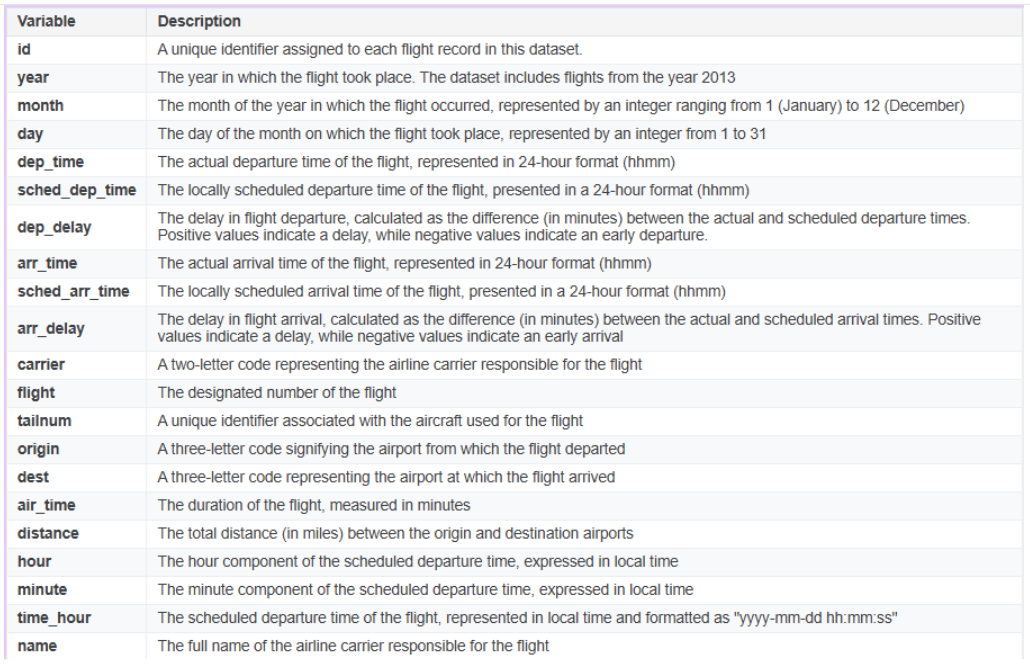

In [2]:
# Importing required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'flight_data.xls')
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,1/1/2013 5:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,1/1/2013 5:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,1/1/2013 5:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,1/1/2013 5:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,1/1/2013 6:00


In [4]:
df.shape

(336776, 19)

#### Observation:
This dataset has 3,36776 rows and 19 columns 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute    

#### Observation :
There are total 19 columns out of which 5 are float, 9 are int and 5 are of object datatype

## Data quality issues 
1. type casting
2. Noisy or inconsistent 
3. Missing values 
4. Duplicates 
5. Outliers 

## 1. Type casting 
the column `time_hour` should be in the datetime datatype. But it si object, we need to change it

In [7]:
df['time_hour'] = pd.to_datetime(df['time_hour'],format='mixed')
#df['time_hour'] = df['time_hour'].astype('datetime64[ns]')

In [8]:
# recheck
df.dtypes


year                       int64
month                      int64
day                        int64
dep_time                 float64
sched_dep_time             int64
dep_delay                float64
arr_time                 float64
sched_arr_time             int64
arr_delay                float64
carrier                   object
flight                     int64
tailnum                   object
origin                    object
dest                      object
air_time                 float64
distance                   int64
hour                       int64
minute                     int64
time_hour         datetime64[ns]
dtype: object

## 2 Noisy or inconstient data 

In [9]:
df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='object')

In [13]:
df['dep_delay'].unique()

array([ 2.000e+00,  4.000e+00, -1.000e+00, -6.000e+00, -4.000e+00,
       -5.000e+00, -3.000e+00, -2.000e+00,  0.000e+00,  1.000e+00,
       -8.000e+00,  8.000e+00,  1.100e+01,  3.000e+00,  1.300e+01,
        2.400e+01, -7.000e+00, -9.000e+00,  9.000e+00,  4.700e+01,
        3.900e+01, -1.000e+01,  5.000e+00,  1.010e+02,  7.000e+00,
        7.100e+01, -1.100e+01,  8.530e+02,  6.000e+00,  4.300e+01,
        2.300e+01,  5.900e+01,  1.200e+01,  1.400e+01,  1.500e+01,
        2.100e+01,  2.500e+01,  2.900e+01, -1.500e+01, -1.300e+01,
        3.200e+01,  1.440e+02,  1.000e+01,  3.400e+01,  1.600e+01,
        1.800e+01,  1.340e+02,  9.600e+01,  3.000e+01,  4.100e+01,
        5.500e+01,  3.700e+01,  2.600e+01,  7.700e+01,  2.200e+01,
        4.000e+01,  5.700e+01,  7.000e+01,  5.600e+01,  3.500e+01,
        3.100e+01,  1.150e+02,  3.800e+01,  5.000e+01,  2.700e+01,
        1.050e+02,  1.220e+02,  8.800e+01,  6.400e+01,  1.190e+02,
        5.400e+01,  8.400e+01,  3.300e+01,  4.200e+01,  5.200e

#### Observation: 
After checking each column , we found that there is no noise in the data 

In [14]:
df['tailnum'].unique()

array(['N14228', 'N24211', 'N619AA', ..., 'N776SK', 'N785SK', 'N557AS'],
      shape=(4044,), dtype=object)

In [15]:
df['tailnum'].nunique()

4043

#### Observation: 
tailnum values are not unique, and it is not making any sense. We can drop this colukn 

In [16]:
df.drop(columns = 'tailnum',axis = 1, inplace = True)

In [17]:
# rechecking
df.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='object')

## 3. Detecting and handling missing values 

In [18]:
df.isnull().sum()

year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

##### 1. dep_time
missing dep_time usually means tht flight was departed on scheduled time/ So we will fill the missing values with sched_dep_time from the same row 

In [19]:
df['dep_time'] = df['dep_time'].fillna(df['sched_dep_time'])

In [20]:
# rechecing 
df.isnull().sum()

year                 0
month                0
day                  0
dep_time             0
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

##### 2. dep_delay 
to fill missing values of dep_delay, subtract sched_dep_time from dep_time


In [ ]:
df['dep_delay'] = df['dep_delay'].fillna(df['dep_time']-df['sched_dep_time'])
or 


or what we can do is, as we have filled the missing values in dep_time with the corresponding sched_dep_time, 
the difference between them is going to be '0'. so we can fill it directly with 0

In [21]:
df['dep_delay'] = df['dep_delay'].fillna(0)

In [22]:
# rechecing 
df.isnull().sum()

year                 0
month                0
day                  0
dep_time             0
sched_dep_time       0
dep_delay            0
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

##### 3. arr_time 
we are assuming that the flights for which arr_time is missing, arrived on the scheduled time. SO we are filling those missing values with their corrsponding sched_arr_time 

In [23]:
df['arr_time'] = df['arr_time'].fillna(df['sched_arr_time'])

##### 4. arr_delay 
let's fill the missing values in this column by calculating the difference between arr_time and sched_arr_time 

In [24]:
df['arr_delay'] = df['arr_delay'].fillna(df['arr_time'] - df['sched_arr_time'])

In [25]:
## rechecking 
df.isnull().sum()

year                 0
month                0
day                  0
dep_time             0
sched_dep_time       0
dep_delay            0
arr_time             0
sched_arr_time       0
arr_delay            0
carrier              0
flight               0
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

#### 5. air_time 
air_time is the time for which the flisht is in the air. We can fill the missing values with the help of dep_time and arr_time . 


In [26]:
df['air_time'] = df['air_time'].fillna(df['arr_time'] - df['dep_time'])

In [27]:
# rechecing 
df.isnull().sum()

year              0
month             0
day               0
dep_time          0
sched_dep_time    0
dep_delay         0
arr_time          0
sched_arr_time    0
arr_delay         0
carrier           0
flight            0
origin            0
dest              0
air_time          0
distance          0
hour              0
minute            0
time_hour         0
dtype: int64

## 4. Detecing and handling duplicates 

In [28]:
df.duplicated().sum()

np.int64(0)

#### Observation: 
There are no duplicate rows in this dataset

## 5. Outliers 

Here, our goal is to analyse airline performance or find which aitport have the worst bottlnecks, so I will not remove the outliers. 
These massive delays are real eventa that reflect operational failures you need to study. 

# Data visualization 

In [30]:
df.dtypes

year                       int64
month                      int64
day                        int64
dep_time                 float64
sched_dep_time             int64
dep_delay                float64
arr_time                 float64
sched_arr_time             int64
arr_delay                float64
carrier                   object
flight                     int64
origin                    object
dest                      object
air_time                 float64
distance                   int64
hour                       int64
minute                     int64
time_hour         datetime64[ns]
dtype: object

## Univariate analaysis 

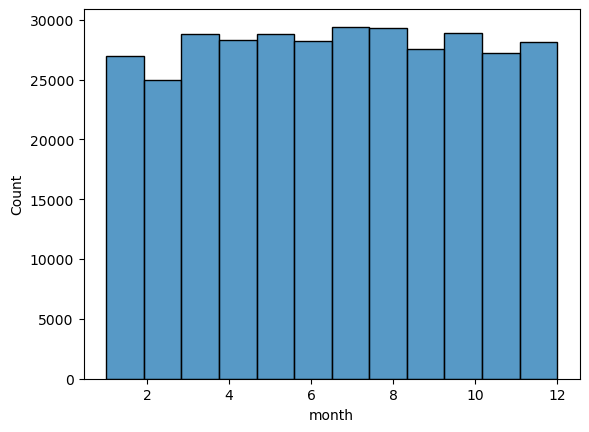

In [34]:

sns.histplot(data = df, x ='month', bins = 12)
plt.show()

In [35]:
## Observation : It shows that the distribution of flights across diffrent months is approximately the same 

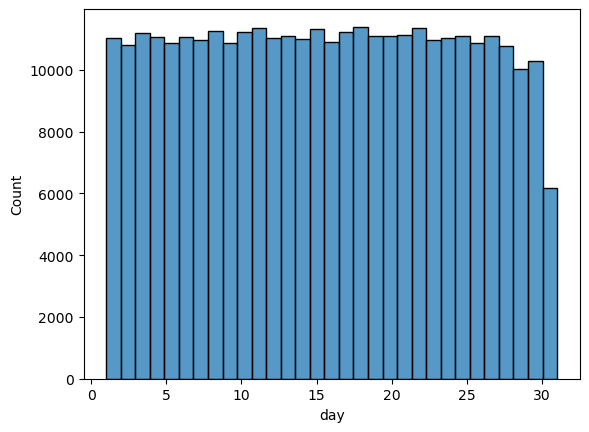

In [37]:

sns.histplot(data = df, x ='day', bins = 31)
plt.show()

In [ ]:
## Observation : The histogram reveals a mostly uniform distribution across the days of month, with slight decrease at the end of month. 
# this decrease is due to the reason that some have fewer days than 31 

<Axes: xlabel='carrier', ylabel='count'>

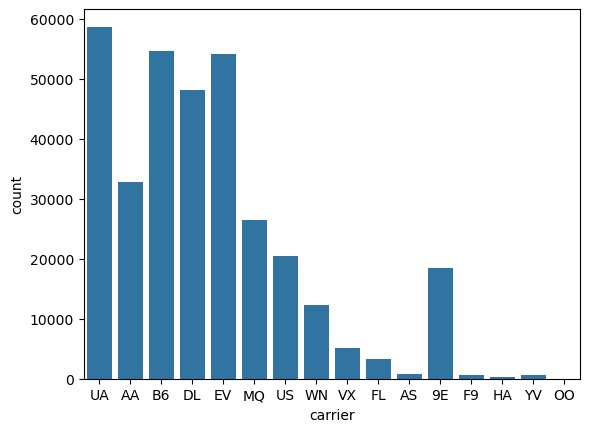

In [38]:
sns.countplot(data = df, x = 'carrier')

In [ ]:
## Observation : The carrier with codes UA,B6, EV and DL operate the most flights in dataset and OO operates min  flights 

<Axes: xlabel='origin', ylabel='count'>

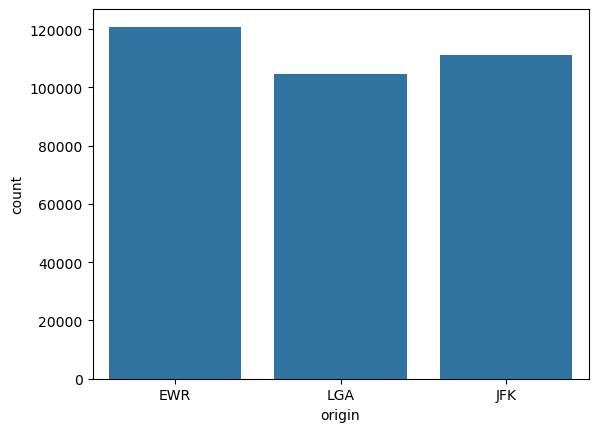

In [39]:
sns.countplot(data = df,x = 'origin')

In [ ]:
# Insight - The countplot shows that the flights departed from EWR are slighltly more as comapred to other two origins 

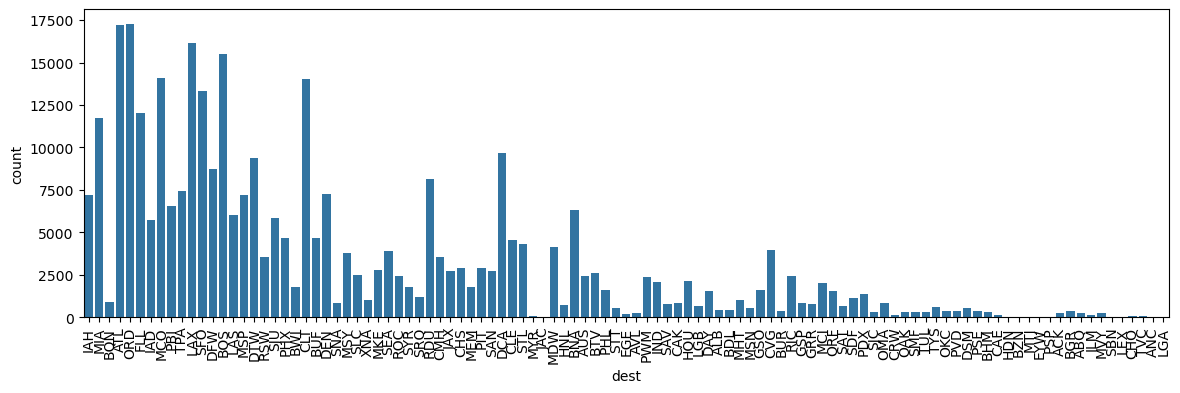

In [44]:
plt.figure(figsize=(14,4))
sns.countplot(data = df,x = 'dest')
plt.xticks(rotation = 90)
plt.show()

In [47]:
top_10 = df['dest'].value_counts().head(10)
top_10

dest
ORD    17283
ATL    17215
LAX    16174
BOS    15508
MCO    14082
CLT    14064
SFO    13331
FLL    12055
MIA    11728
DCA     9705
Name: count, dtype: int64

In [52]:
df_top = df[df['dest'].isin(top_10.index)]
df_top

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,origin,dest,air_time,distance,hour,minute,time_hour
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00
5,2013,1,1,554.0,558,-4.0,740.0,728,12.0,UA,1696,EWR,ORD,150.0,719,5,58,2013-01-01 05:00:00
6,2013,1,1,555.0,600,-5.0,913.0,854,19.0,B6,507,EWR,FLL,158.0,1065,6,0,2013-01-01 06:00:00
8,2013,1,1,557.0,600,-3.0,838.0,846,-8.0,B6,79,JFK,MCO,140.0,944,6,0,2013-01-01 06:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336755,2013,9,30,2149.0,2156,-7.0,2245.0,2308,-23.0,UA,523,EWR,BOS,37.0,200,21,56,2013-09-30 21:00:00
336762,2013,9,30,2233.0,2113,80.0,112.0,30,42.0,UA,471,EWR,SFO,318.0,2565,21,13,2013-09-30 21:00:00
336763,2013,9,30,2235.0,2001,154.0,59.0,2249,130.0,B6,1083,JFK,MCO,123.0,944,20,1,2013-09-30 20:00:00
336768,2013,9,30,2307.0,2255,12.0,2359.0,2358,1.0,B6,718,JFK,BOS,33.0,187,22,55,2013-09-30 22:00:00


<Axes: xlabel='dest', ylabel='count'>

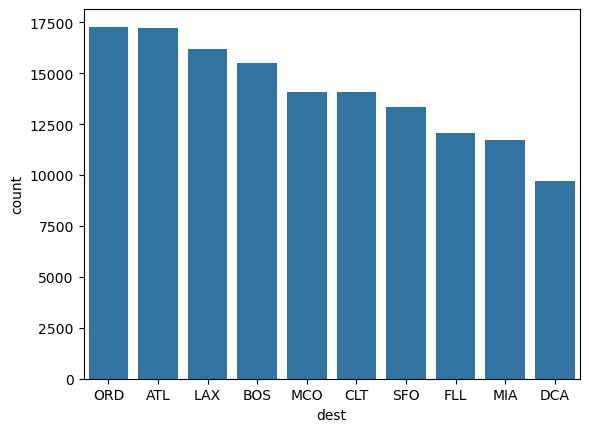

In [55]:
sns.countplot(data = df_top, x = 'dest', order = top_10.index)

## bi variate analysis 

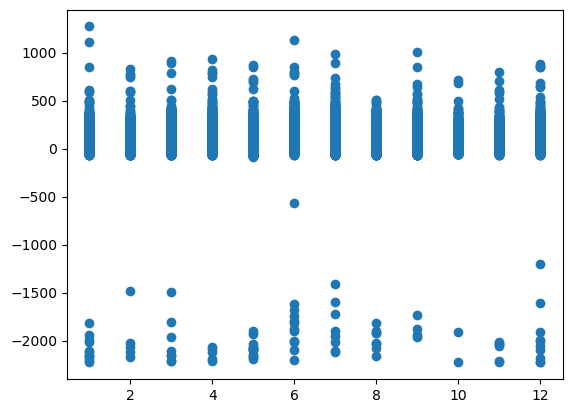

In [56]:
plt.scatter(df['month'], df['arr_delay'])

In [ ]:
# Insight : Month does not have a significatnt impact on the arr_ delay of flights 

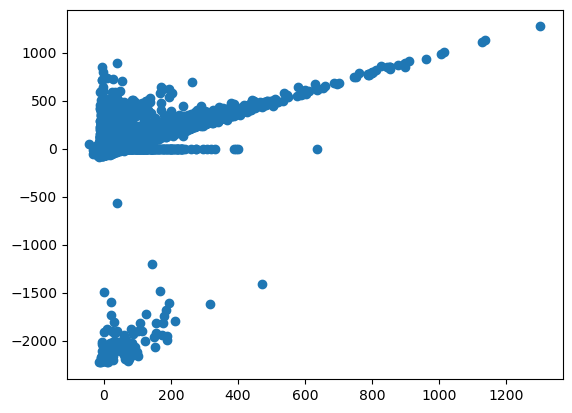

In [57]:
plt.scatter(df['dep_delay'],df['arr_delay'])

In [ ]:
# Insight : There is positive relationship between arr_delay and dep_delay 

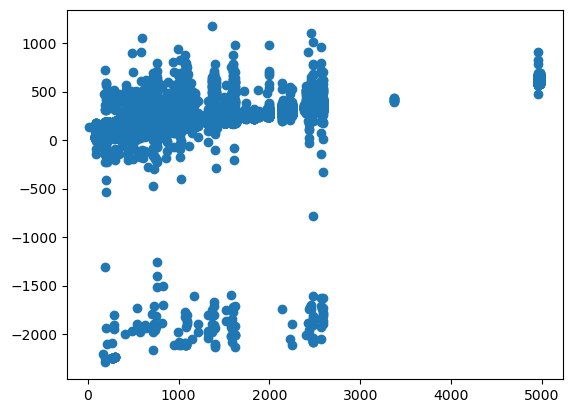

In [58]:
plt.scatter(df['distance'],df['air_time'])

## multi variate analysis 

In [59]:
num_df = df.select_dtypes(include = 'number')
num_df

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,1545,227.0,1400,5,15
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,1714,227.0,1416,5,29
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,1141,160.0,1089,5,40
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,725,183.0,1576,5,45
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,461,116.0,762,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,1455.0,1455,0.0,1634.0,1634,0.0,3393,179.0,213,14,55
336772,2013,9,30,2200.0,2200,0.0,2312.0,2312,0.0,3525,112.0,198,22,0
336773,2013,9,30,1210.0,1210,0.0,1330.0,1330,0.0,3461,120.0,764,12,10
336774,2013,9,30,1159.0,1159,0.0,1344.0,1344,0.0,3572,185.0,419,11,59


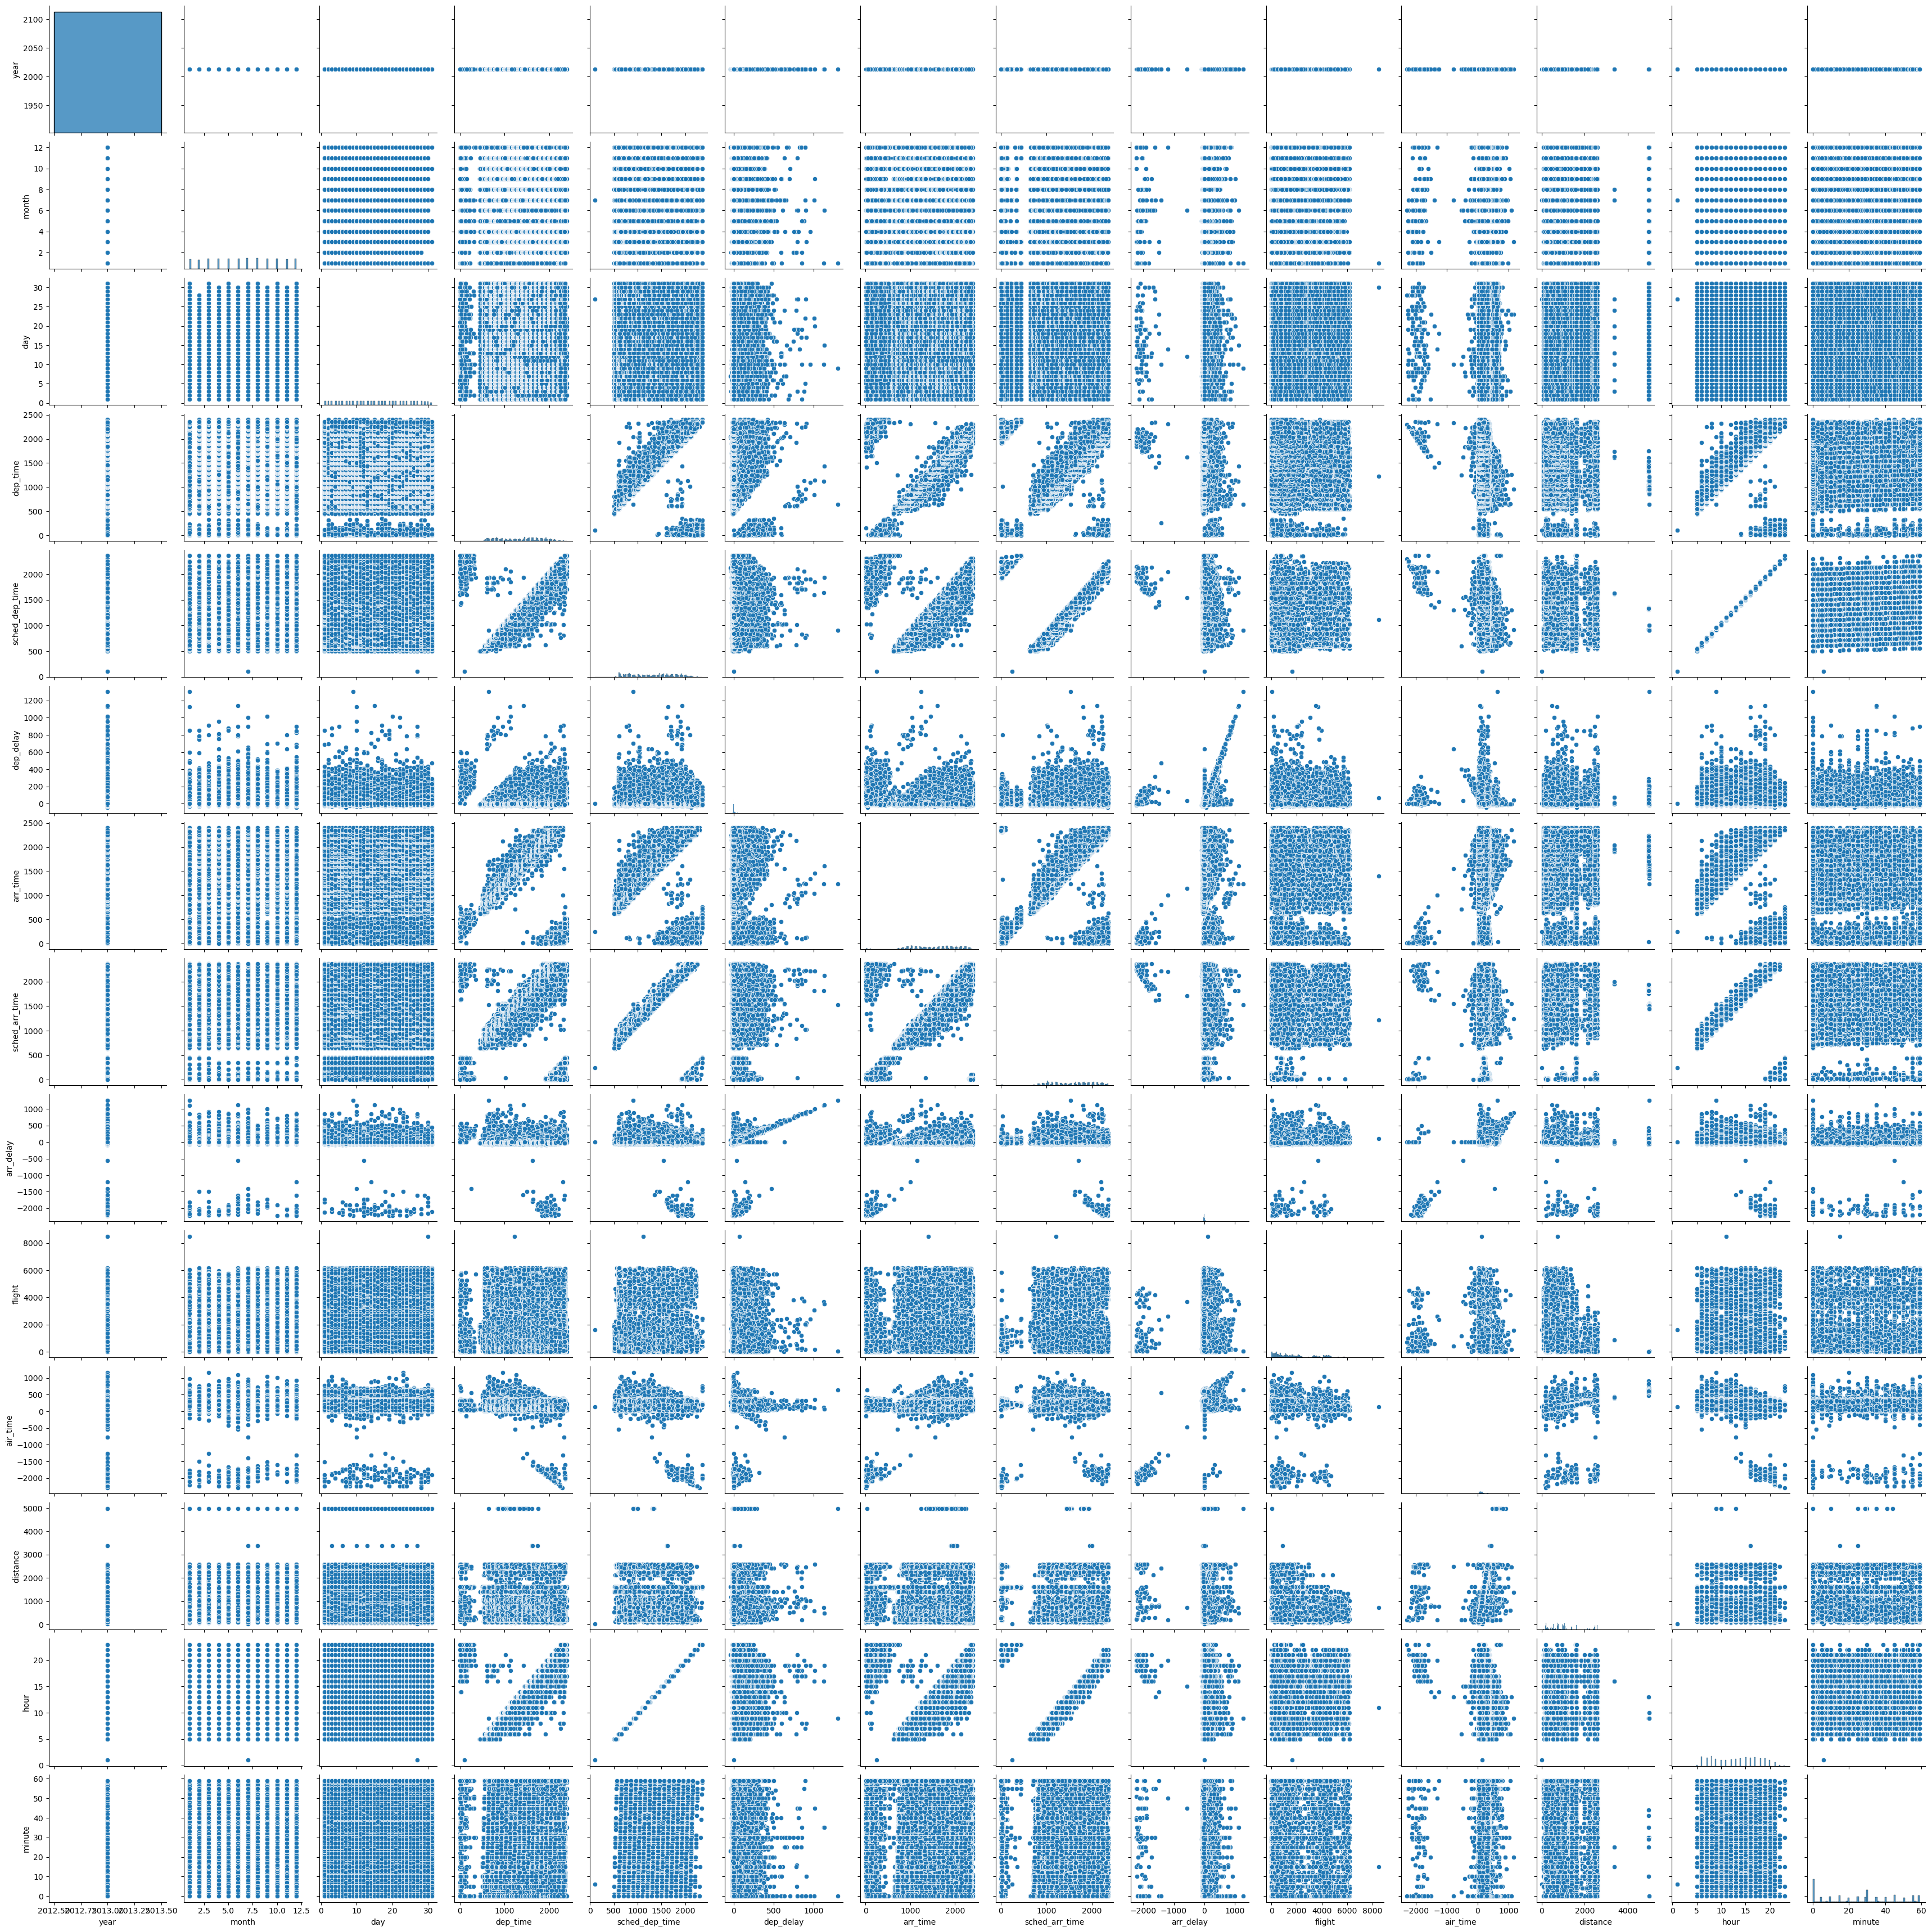

In [61]:
sns.pairplot(num_df)

<Axes: >

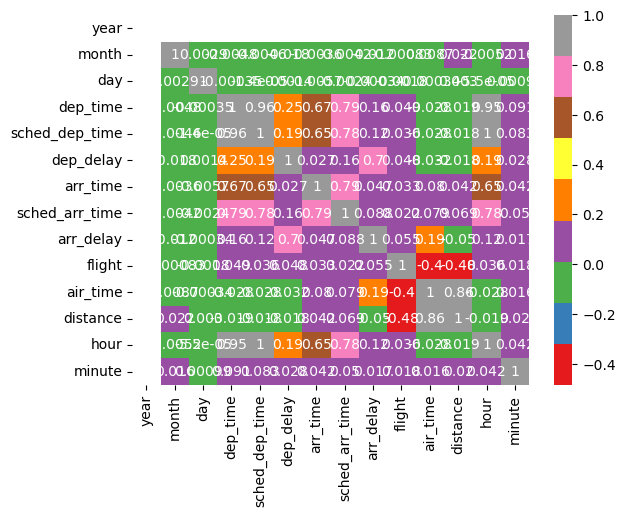

In [62]:
sns.heatmap(num_df.corr(), annot = True,cmap = 'Set1')